In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
import pandas as pd
import json
import geopandas as gpd

ROOT_DIR = Path().resolve().parent
sys.path.insert(0, str(ROOT_DIR))

from scripts.helpers.datasets import load_taxi_data
from scripts.helpers.preprocessing import evaluate_weather_zones, get_weather_zone_centers
from scripts.download_weather_data import download_weather_data

## Identify optimal number & location of different weather stations

Based on the trips, in particular the centroid coordinates of the pickup point, we use k-means to identify the optimal positions to draw on weather data

In [2]:
df = load_taxi_data(preprocessed=True)
coords = df[["pickup_centroid_latitude", "pickup_centroid_longitude"]].dropna().values

In [3]:
# 1. Calculate metrics
metrics = evaluate_weather_zones(coords, k_range=range(2, 10))

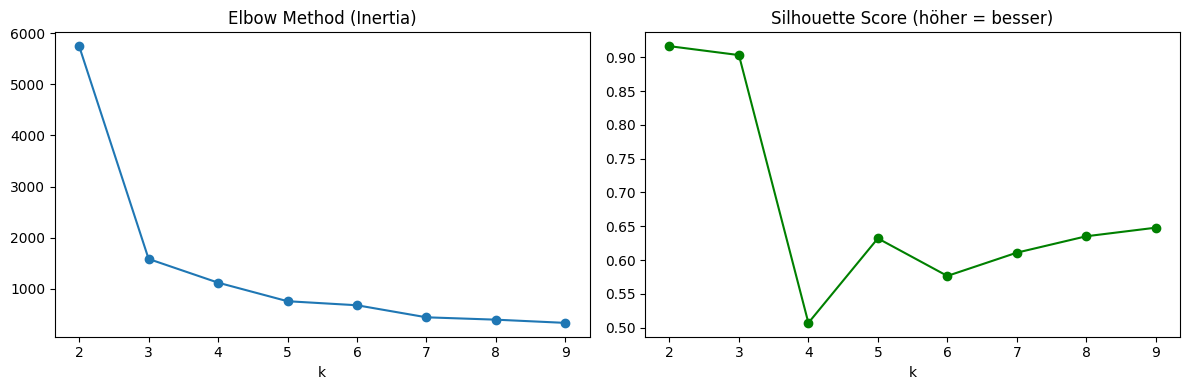

In [4]:
# 2. Visualize metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

metrics["inertia"].plot(ax=ax1, marker="o")
ax1.set_xlabel("k")
ax1.set_title("Elbow Method (Inertia)")

metrics["silhouette"].plot(ax=ax2, marker="o", color="green")
ax2.set_xlabel("k")
ax2.set_title("Silhouette Score (höher = besser)")

plt.tight_layout()
plt.show()

In [5]:
# 3. Choose k=3 based on metrics and calculate zone centers + save to JSON
weather_zones = get_weather_zone_centers(coords, n_clusters=3)
with open(ROOT_DIR / "data" / "raw" / "weather_zones.json", "w") as f:
    json.dump(weather_zones, f, indent=4)
print(weather_zones)
# → {'zone_1': (41.88, -87.63), 'zone_2': ..., ...}

{0: (41.785010867244395, -87.74926762290268), 1: (41.885763061544985, -87.6288473909976), 2: (41.97908725018207, -87.90289694889694)}


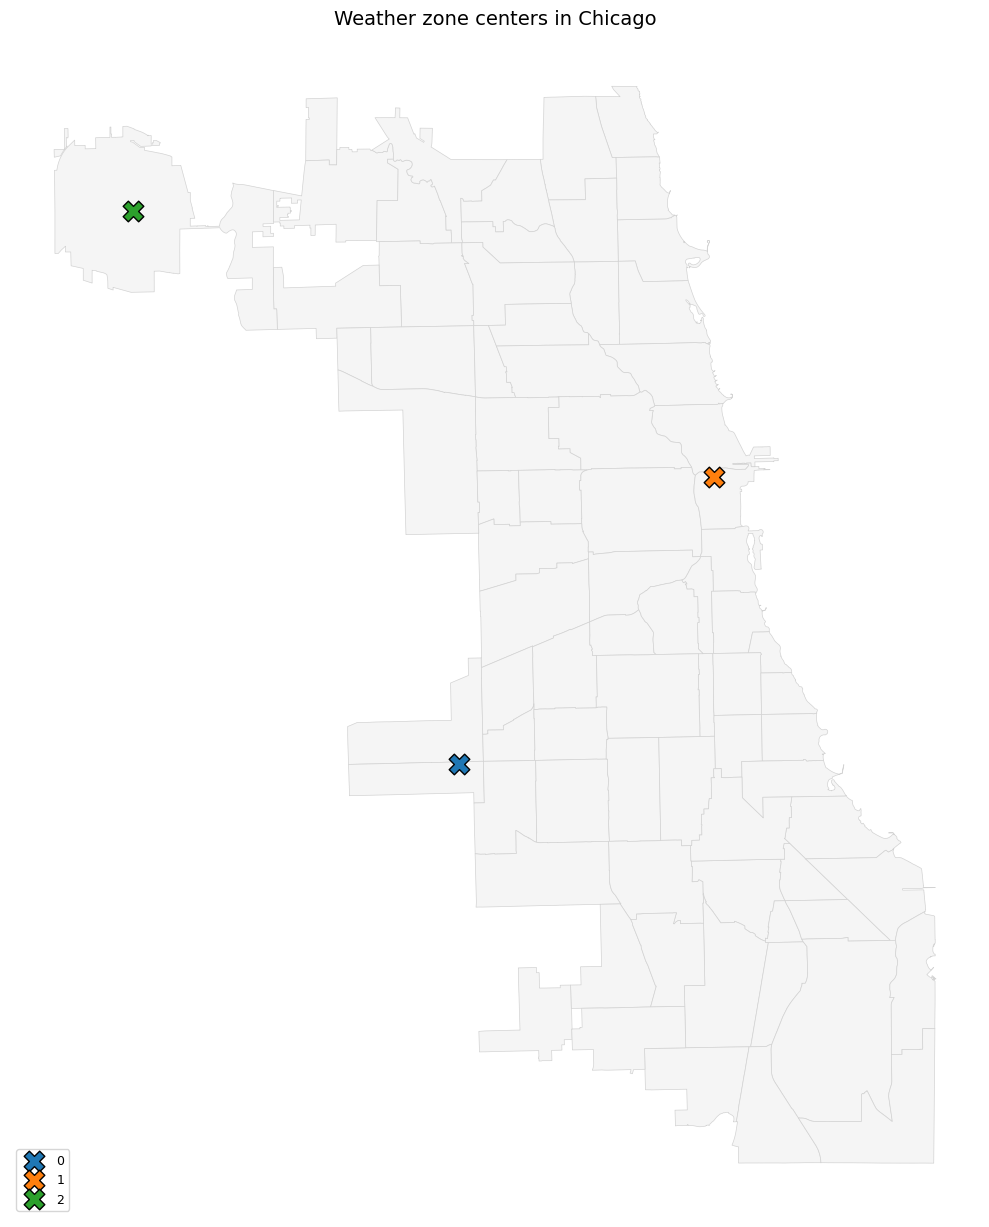

In [7]:
# 4. Plot Chicago basemap + weather zones (zone centers only)
ca_gdf = gpd.read_file(ROOT_DIR / "data" / "raw" / "community_areas.geojson")
if ca_gdf.crs is not None and ca_gdf.crs.to_epsg() != 4326:
    ca_gdf = ca_gdf.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10, 14))
ca_gdf.plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.5)

# Weather zone centers
for zone, (lat, lon) in weather_zones.items():
    ax.scatter(
        lon, lat,
        marker="X", s=220,
        linewidths=1, edgecolors="black",
        label=zone,
    )

ax.legend(loc="lower left", fontsize=9, framealpha=0.8)
ax.set_title("Weather zone centers in Chicago", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Identify the needed timeframe

By searching for the timestamp of the first and last trip we can identify the timeframe for  when we need the weather data

In [6]:
first_trip = df['trip_start_timestamp'].min().date()
last_trip = df['trip_end_timestamp'].max().date()

In [7]:
df_weather = download_weather_data(weather_zones, first_trip, last_trip)
df_weather.head()

   Period : 2024-01-01 → 2026-05-01
   Zones  : 3

   Fetching 0  (41.9791, -87.9029) … 20,448 rows
   Fetching 1  (41.8858, -87.6288) … 20,448 rows
   Fetching 2  (41.7850, -87.7493) … 20,448 rows

Done.
   Rows saved : 61,344  (3 zones × ~20,448 hours)
   Output     : /home/timo/uni/AAA/AAA26-Chicago-Mobility/data/raw/chicago_weather_hourly.csv


,time,temperature_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,windspeed_10m,windgusts_10m,weather_code,cloud_cover,zone,latitude,longitude
0,2024-01-01 00:00:00,-0.2,-5.6,0.0,0.0,0.0,0.01,18.3,34.2,3,100,0,41.979087,-87.902897
1,2024-01-01 01:00:00,-0.3,-5.8,0.0,0.0,0.0,0.01,19.1,36.0,3,100,0,41.979087,-87.902897
2,2024-01-01 02:00:00,-0.6,-6.0,0.0,0.0,0.0,0.01,18.5,36.0,3,99,0,41.979087,-87.902897
3,2024-01-01 03:00:00,-1.0,-6.3,0.0,0.0,0.0,0.01,16.8,34.6,3,97,0,41.979087,-87.902897
4,2024-01-01 04:00:00,-1.8,-6.8,0.0,0.0,0.0,0.01,15.2,31.0,2,59,0,41.979087,-87.902897


In [8]:
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 61344 entries, 0 to 61343
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  61344 non-null  datetime64[us]
 1   temperature_2m        61344 non-null  float64       
 2   apparent_temperature  61344 non-null  float64       
 3   precipitation         61344 non-null  float64       
 4   rain                  61344 non-null  float64       
 5   snowfall              61344 non-null  float64       
 6   snow_depth            61344 non-null  float64       
 7   windspeed_10m         61344 non-null  float64       
 8   windgusts_10m         61344 non-null  float64       
 9   weather_code          61344 non-null  int64         
 10  cloud_cover           61344 non-null  int64         
 11  zone                  61344 non-null  int64         
 12  latitude              61344 non-null  float64       
 13  longitude             61344

In [9]:
print(df_weather.isnull().sum())

time                    0
temperature_2m          0
apparent_temperature    0
precipitation           0
rain                    0
snowfall                0
snow_depth              0
windspeed_10m           0
windgusts_10m           0
weather_code            0
cloud_cover             0
zone                    0
latitude                0
longitude               0
dtype: int64


## Check for duplicates

In [10]:
print(df_weather.duplicated(subset=['time', 'zone']).sum())

0


## Drop not needed colunms

As precipitation is derivable from the rain & snow column (precipitation = rain + snowfall) this coulmn will be dropped as it doesn't provide any neew info. The reason for using rain & snow fall instead of just precipitation is that rain and snow have different behavioral effects. While rain typically increases demand, heavy snow leads to an decrease in demand. Creating categorical categories from these features is not needed as it's done though the weather_code 

In [11]:
df_weather.drop(columns=['precipitation'], inplace=True)

Maybe drop one of the following `apparent_termperature` or `tmeperature_2m`

## Feature Engineering

The raw `weather_code` column uses WMO (World Meteorological Organization) integer codes ranging from 0–99. These codes are **not ordinal** — a code of 95 (thunderstorm) does not mean "95× worse" than code 1 (clear sky). Feeding raw integers into an SVM or neural network would imply a false numeric ordering that the model would misinterpret.

Instead, the codes are binned into 7 meaningful categories based on the WMO standard:

| Code range | Category |
|---|---|
| 0–3 | clear |
| 45–48 | fog |
| 51–67 | rain (incl. drizzle & freezing rain) |
| 71–77 | snow |
| 80–82 | showers |
| 85–86 | snow showers |
| 95–99 | storm |

Note: codes 4–44 and 68–70 do not exist in the WMO standard — hence the non-continuous boundaries.

These categories are then one-hot encoded using `pd.get_dummies` with `drop_first=True` to avoid the dummy variable trap (perfect multicollinearity). The main value over the existing `rain`/`snowfall` columns is that `weather_code` also captures **fog** 

In [12]:
print(df_weather['weather_code'].unique())

[ 3  2  0  1 71 73 75 61 63 53 51 55 65]


In [13]:
def categorize_weather_code(code):
    if code <= 3:
        return "clear"
    elif code <= 48:
        return "fog"
    elif code <= 67:
        return "rain"
    elif code <= 77:
        return "snow"
    elif code <= 82:
        return "showers"
    elif code <= 86:
        return "snow_showers"
    else:
        return "storm"


In [14]:
print(df_weather.columns)

Index(['time', 'temperature_2m', 'apparent_temperature', 'rain', 'snowfall',
       'snow_depth', 'windspeed_10m', 'windgusts_10m', 'weather_code',
       'cloud_cover', 'zone', 'latitude', 'longitude'],
      dtype='str')


In [15]:
df_weather['weather_category'] = df_weather['weather_code'].apply(categorize_weather_code)
df_weather = pd.get_dummies(df_weather, columns=['weather_category'], drop_first=True)
df_weather.drop(columns=['weather_code'], inplace=True)


In [16]:
df_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 61344 entries, 0 to 61343
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   time                   61344 non-null  datetime64[us]
 1   temperature_2m         61344 non-null  float64       
 2   apparent_temperature   61344 non-null  float64       
 3   rain                   61344 non-null  float64       
 4   snowfall               61344 non-null  float64       
 5   snow_depth             61344 non-null  float64       
 6   windspeed_10m          61344 non-null  float64       
 7   windgusts_10m          61344 non-null  float64       
 8   cloud_cover            61344 non-null  int64         
 9   zone                   61344 non-null  int64         
 10  latitude               61344 non-null  float64       
 11  longitude              61344 non-null  float64       
 12  weather_category_rain  61344 non-null  bool          
 13  weather_cate

## Loading & Preprocessing in Subsequent Notebooks

All steps documented above are encapsulated in two helper scripts so that later notebooks can load a clean dataset in a single line:

- **`scripts/helpers/datasets.py`** — entry point for loading any dataset. `load_weather_data(preprocessed=True)` reads the raw CSV and optionally applies the full preprocessing pipeline.
- **`scripts/helpers/preprocessing.py`** — contains `preprocess_weather_data()`, which drops irrelavant rows, handles weather_code and returns a clean `DataFrame`.

Usage in any subsequent notebook:

```python
from scripts.helpers.datasets import load_weather_data, load_merged_data

df = load_weather_data(preprocessed=True)       # cleaned dataset
df_raw = load_weather_data(preprocessed=False)  # raw data only
df_merged = load_merged_data() # preprocessed taxi + weather data
```